# WB6 Population Density (WorldPop 2020)

**Western Balkans 6 — Albania, Bosnia-Herzegovina, Kosovo, Montenegro, N. Macedonia, Serbia**

Data: WorldPop UN-adjusted population density rasters (~1 km resolution, 2020).  
Kosovo (XKX) is not hosted as a standalone dataset on WorldPop; it is extracted by clipping Serbia's raster to Kosovo's boundary polygon.

**Author**: Md Eliasinul Islam, Sustainable Energy Engineering, Simon Fraser University

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
from pathlib import Path
import warnings
import requests
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.merge import merge as rmerge
from rasterio.features import rasterize
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.patheffects import withStroke
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
print('Imports OK')

Imports OK


In [2]:
# ── Config ───────────────────────────────────────────────────────────────────
BASE_DIR   = Path('..').resolve()
RAW_DIR    = BASE_DIR /'data' / 'downloaded_data' / 'worldpop' / 'raw'
PROC_DIR   = BASE_DIR / 'data' / 'downloaded_data' / 'worldpop' / 'processed'
MAPS_DIR   = BASE_DIR / 'data' / 'downloaded_data' / 'worldpop' / 'maps'
for d in [RAW_DIR, PROC_DIR, MAPS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

COUNTRIES = {
    'AL': {'iso3': 'ALB', 'label': 'Albania'},
    'BA': {'iso3': 'BIH', 'label': 'Bosnia-Herzegovina'},
    'ME': {'iso3': 'MNE', 'label': 'Montenegro'},
    'XK': {'iso3': 'KOS', 'label': 'Kosovo'}, # they use KOS instead of XKX, but XKX is the ISO3 code for Kosovo
    'MK': {'iso3': 'MKD', 'label': 'N. Macedonia'},
    'RS': {'iso3': 'SRB', 'label': 'Serbia'},
}

FALLBACK_YEARS = [2020, 2019, 2018, 2015]

# Discrete classification bins (people / km²)
BINS   = [0, 1, 5, 25, 100, 500, 2000, np.inf]
COLORS = ['#f7f7f7','#d9f0a3','#addd8e','#78c679','#31a354','#006837','#00441b']
LABELS = ['< 1','1 – 5','5 – 25','25 – 100','100 – 500','500 – 2 000','> 2 000']

CMAP_DISC = mcolors.ListedColormap(COLORS)
NORM_DISC = mcolors.BoundaryNorm(BINS[:-1] + [BINS[-2]*10], len(COLORS))

print('Config OK')

Config OK


In [3]:
# ── load your existing boundaries GDF ────────────────────────────────────────
# Replace this line with however you already load your GDF, e.g.:
#   boundaries_gdf = gpd.read_file("path/to/wb6_boundaries.gpkg")
#   boundaries_gdf = your_existing_variable

BOUNDARY_FILE = BASE_DIR /"data/processed_data/WB6_boundary.geojson"   # ← set your path
boundaries_gdf = gpd.read_file(BOUNDARY_FILE)

# ── normalise to EPSG:4326 ────────────────────────────────────────────────────
if boundaries_gdf.crs.to_epsg() != 4326:
    boundaries_gdf = boundaries_gdf.to_crs("EPSG:4326")

# ── set ISO2 as the index for easy lookup ─────────────────────────────────────
ISO2_COLUMN = "ISO2"     # ← change to the column that holds AL / BA / XK …
boundaries_gdf = boundaries_gdf.set_index(ISO2_COLUMN)

# ── quick sanity check ────────────────────────────────────────────────────────
print(f"CRS     : {boundaries_gdf.crs}")
print(f"Rows    : {len(boundaries_gdf)}")
print(f"Columns : {list(boundaries_gdf.columns)}")
boundaries_gdf

CRS     : EPSG:4326
Rows    : 6
Columns : ['Country', 'geometry']


,Country,geometry
ISO2,,
AL,Albania,"MULTIPOLYGON (((20.1153 39.6623, 20.0897 39.67..."
BA,Bosnia and Herzegovina,"POLYGON ((18.9897 44.8614, 19.01 44.8644, 19.0..."
XK,Kosovo,"POLYGON ((20.5829 41.9061, 20.5822 41.9114, 20..."
ME,Montenegro,"MULTIPOLYGON (((19.1379 41.9935, 19.1393 41.99..."
MK,North Macedonia,"POLYGON ((20.9335 40.9208, 20.9114 40.9139, 20..."
RS,Serbia,"MULTIPOLYGON (((20.4512 42.9111, 20.4577 42.90..."


- Population Density

In [4]:
# ── WorldPop URL builder ─────────────────────────────────────────────────────
def worldpop_urls(iso2: str, year: int) -> list:
    """Return candidate WorldPop download URLs for a country/year."""
    iso3 = COUNTRIES[iso2]['iso3'].lower()
    ISO3 = iso3.upper()
    templates = [
        f'https://data.worldpop.org/GIS/Population_Density/Global_2000_2020_1km_UNadj/{year}/{ISO3}/{iso3}_pd_{year}_1km_UNadj.tif',
        f'https://data.worldpop.org/GIS/Population_Density/Global_2000_2020_1km/{year}/{ISO3}/{iso3}_pd_{year}_1km.tif',
        f'https://data.worldpop.org/GIS/Population_Density/Global_2000_2020_1km_UNadj/{year}/{ISO3}/{iso3}_pd_{year}_1km_UNadj_UNadj.tif',
    ]
    return templates

print('URL builder OK')

URL builder OK


- Population 

In [6]:
# ── Download helper ───────────────────────────────────────────────────────────
def download_country(iso2: str, year: int, out_dir: Path) -> Path | None:
    """Download WorldPop raster for iso2/year. Returns Path or None on failure."""
    iso3 = COUNTRIES[iso2]['iso3'].lower()
    fname = out_dir / f'{iso3}_pd_{year}_raw.tif'
    if fname.exists() and fname.stat().st_size > 50_000:
        print(f'  [{iso2}] cached → {fname.name}')
        return fname
    for url in worldpop_urls(iso2, year):
        try:
            r = requests.get(url, timeout=120, stream=True)
            if r.status_code != 200:
                print(f'  [{iso2}] HTTP {r.status_code}: {url}')
                continue
            with open(fname, 'wb') as fh:
                for chunk in r.iter_content(1 << 20):
                    fh.write(chunk)
            print(f'  [{iso2}] downloaded → {fname.name} ({fname.stat().st_size/1e6:.1f} MB)')
            return fname
        except Exception as exc:
            print(f'  [{iso2}] error: {exc}')
    return None

print('Download helper OK')

Download helper OK


In [7]:
# ── Batch download (WorldPop-available countries) + Kosovo fallback ───────────
#
# WorldPop does NOT host a standalone Kosovo (XKX) raster — all URL variants
# return HTTP 404. Kosovo is extracted by clipping Serbia's raw raster to the
# Kosovo boundary polygon constructed in Cell 3.
# Serbia (RS) is downloaded in the main loop; Kosovo step runs AFTER the loop
# so that raw_paths['RS'] is guaranteed to be available.

raw_paths = {}

# ── Step 1: Download the 5 countries WorldPop carries ─────────────────────────
for iso2 in ['AL', 'BA', 'ME', 'MK', 'RS','XK']:
    label = COUNTRIES[iso2]['label']
    print(f'\n> {label} ({iso2})')
    result = None
    for yr in FALLBACK_YEARS:
        result = download_country(iso2, yr, RAW_DIR)
        if result:
            break
        print(f'  [{label}] {yr} not available')
    if result:
        raw_paths[iso2] = result
    else:
        print(f'  [{label}] SKIPPED — no data found')

# # ── Step 2: Kosovo — clip Serbia's raw raster to Kosovo boundary ───────────────
# # Runs AFTER main loop so raw_paths['RS'] is guaranteed to exist.
# print('\n> Kosovo (XK) — extracting from Serbia raster')
# serbia_raw = raw_paths.get('RS')
# xk_raw_out = RAW_DIR / 'xkx_pd_from_srb.tif'

# if serbia_raw is None:
#     print('  [XK] Serbia raster not available — Kosovo cannot be extracted')
# elif xk_raw_out.exists() and xk_raw_out.stat().st_size > 10_000:
#     print(f'  [XK] cached → {xk_raw_out.name}')
#     raw_paths['XK'] = xk_raw_out
# else:
#     xk_geom = boundaries_gdf.loc[['XK']].geometry
#     with rasterio.open(serbia_raw) as src:
#         geom_proj = xk_geom.to_crs(src.crs)
#         clipped, clip_tf = rio_mask(src, list(geom_proj.geometry),
#                                      crop=True, nodata=np.nan, filled=True)
#         meta = src.meta.copy()
#     meta.update({'driver': 'GTiff', 'dtype': 'float32',
#                  'height': clipped.shape[1], 'width': clipped.shape[2],
#                  'transform': clip_tf, 'nodata': np.nan, 'compress': 'lzw'})
#     with rasterio.open(xk_raw_out, 'w', **meta) as dst:
#         dst.write(clipped)
#     sz = xk_raw_out.stat().st_size
#     print(f'  [XK] extracted → {xk_raw_out.name} ({sz/1e6:.1f} MB)')
#     raw_paths['XK'] = xk_raw_out

print('\nraw_paths:', {k: v.name for k, v in raw_paths.items()})


> Albania (AL)
  [AL] cached → alb_pd_2020_raw.tif

> Bosnia-Herzegovina (BA)
  [BA] cached → bih_pd_2020_raw.tif

> Montenegro (ME)
  [ME] cached → mne_pd_2020_raw.tif

> N. Macedonia (MK)
  [MK] cached → mkd_pd_2020_raw.tif

> Serbia (RS)
  [RS] cached → srb_pd_2020_raw.tif

> Kosovo (XK)
  [XK] cached → kos_pd_2020_raw.tif

raw_paths: {'AL': 'alb_pd_2020_raw.tif', 'BA': 'bih_pd_2020_raw.tif', 'ME': 'mne_pd_2020_raw.tif', 'MK': 'mkd_pd_2020_raw.tif', 'RS': 'srb_pd_2020_raw.tif', 'XK': 'kos_pd_2020_raw.tif'}


In [8]:
# ── Inventory of downloaded rasters ──────────────────────────────────────────
print(f'{'Country':<20} {'File':<45} {'Size (MB)':>10} {'CRS':<20} {'Shape'}')
print('-' * 110)
for iso2, path in raw_paths.items():
    with rasterio.open(path) as src:
        crs  = str(src.crs)
        shp  = f'{src.height} × {src.width}'
    sz = path.stat().st_size / 1e6
    print(f'{COUNTRIES[iso2]["label"]:<20} {path.name:<45} {sz:>10.1f} {crs:<20} {shp}')

Country              File                                           Size (MB) CRS                  Shape
--------------------------------------------------------------------------------------------------------------
Albania              alb_pd_2020_raw.tif                                  0.2 EPSG:4326            361 × 215
Bosnia-Herzegovina   bih_pd_2020_raw.tif                                  0.4 EPSG:4326            325 × 466
Montenegro           mne_pd_2020_raw.tif                                  0.1 EPSG:4326            207 × 223
N. Macedonia         mkd_pd_2020_raw.tif                                  0.2 EPSG:4326            177 × 306
Serbia               srb_pd_2020_raw.tif                                  0.6 EPSG:4326            475 × 500
Kosovo               kos_pd_2020_raw.tif                                  0.1 EPSG:4326            175 × 217


In [9]:
# ── Clip each raw raster to its country boundary ─────────────────────────────
# Masking BEFORE merging is critical to avoid rectangular bounding-box artefacts
# in the composite map when rasters from different projections are merged.

processed_paths = {}

for iso2, raw_path in raw_paths.items():
    out_path = PROC_DIR / f'{COUNTRIES[iso2]["iso3"].lower()}_pd_clipped.tif'
    if out_path.exists() and out_path.stat().st_size > 10_000:
        processed_paths[iso2] = out_path
        print(f'  [{iso2}] cached → {out_path.name}')
        continue

    label  = COUNTRIES[iso2]['label']
    iso3   = COUNTRIES[iso2]['iso3']
    geom   = boundaries_gdf.loc[[iso2]].geometry

    with rasterio.open(raw_path) as src:
        geom_proj = geom.to_crs(src.crs)
        masked, msk_tf = rio_mask(src, list(geom_proj.geometry),
                                   crop=True, nodata=np.nan, filled=True)
        meta = src.meta.copy()

    meta.update({'driver': 'GTiff', 'dtype': 'float32',
                 'height': masked.shape[1], 'width': masked.shape[2],
                 'transform': msk_tf, 'nodata': np.nan, 'compress': 'lzw'})
    with rasterio.open(out_path, 'w', **meta) as dst:
        dst.write(masked)

    print(f'  [{iso2}] {label} clipped → {out_path.name}')
    processed_paths[iso2] = out_path

print('\nprocessed_paths:', {k: v.name for k, v in processed_paths.items()})

  [AL] cached → alb_pd_clipped.tif
  [BA] cached → bih_pd_clipped.tif
  [ME] cached → mne_pd_clipped.tif
  [MK] cached → mkd_pd_clipped.tif
  [RS] cached → srb_pd_clipped.tif
  [XK] cached → kos_pd_clipped.tif

processed_paths: {'AL': 'alb_pd_clipped.tif', 'BA': 'bih_pd_clipped.tif', 'ME': 'mne_pd_clipped.tif', 'MK': 'mkd_pd_clipped.tif', 'RS': 'srb_pd_clipped.tif', 'XK': 'kos_pd_clipped.tif'}


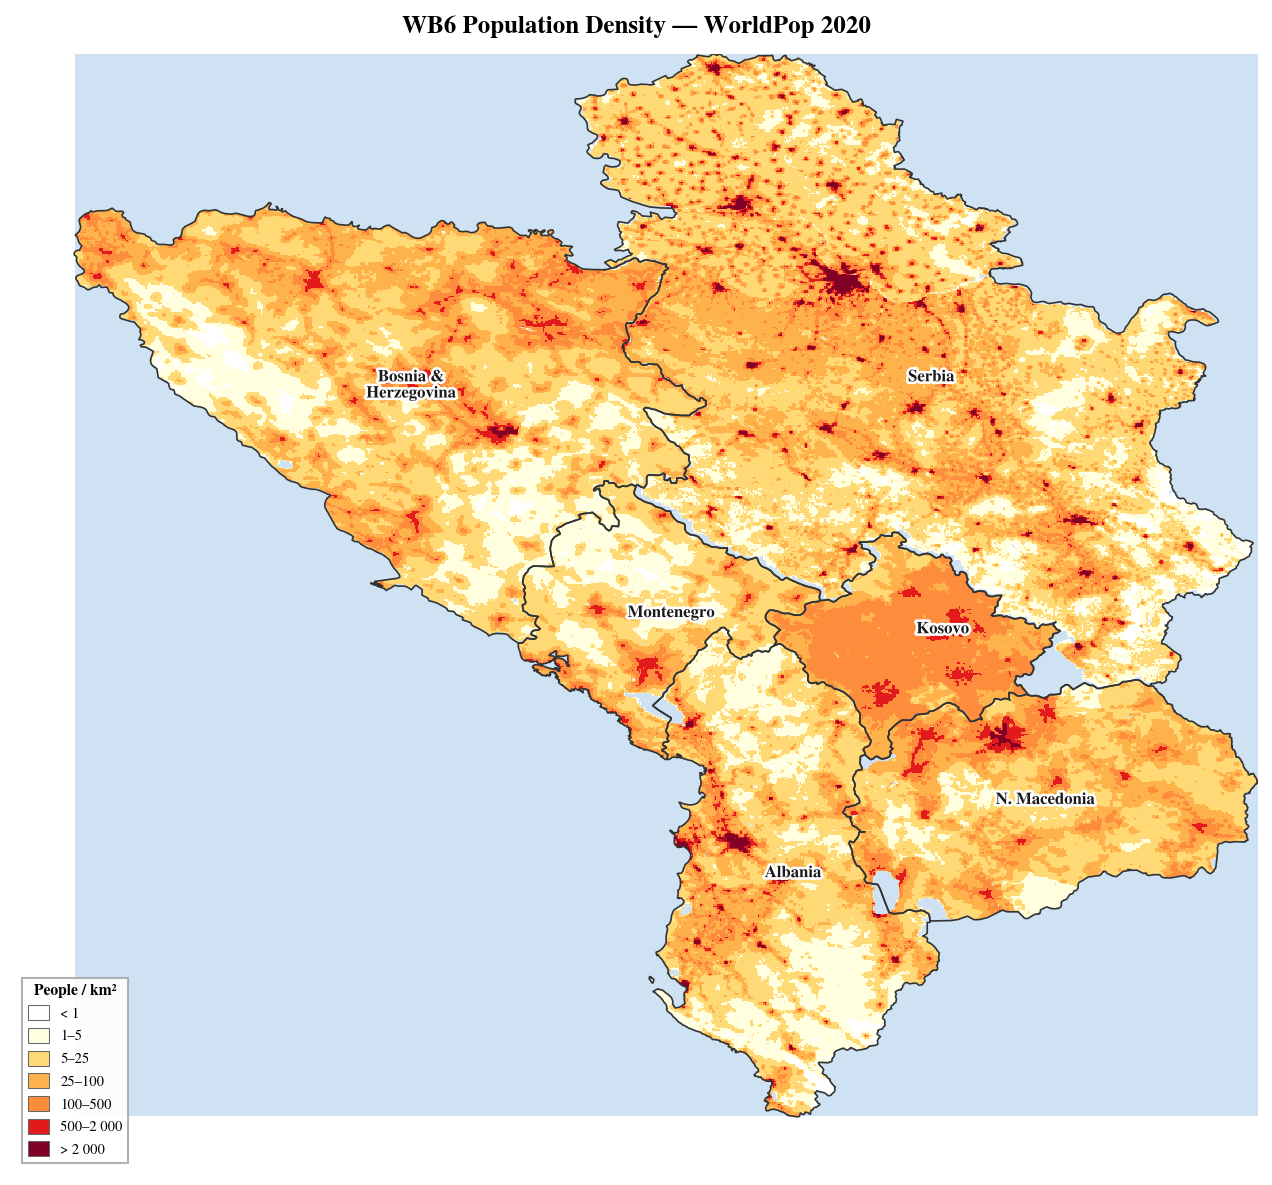

Saved → /local-scratch/localhome/mei3/eliasinul/work/RESource/data/downloaded_data/worldpop/maps/WB6_population_density_composite.png


In [10]:
import matplotlib.patheffects as pe
from rasterio.merge import merge as rmerge
from matplotlib.patches import Patch

# ── Standard CartoDB/GHS population density palette (7 classes) ───────────────
BINS   = [0, 1, 5, 25, 100, 500, 2000, np.inf]
COLORS = ["#FFFFFF",   # <1       — uninhabited / very sparse
          "#FFFFE0",   # 1–5      — rural
          "#FED976",   # 5–25     — low density
          "#FEB24C",   # 25–100   — peri-urban fringe
          "#FD8D3C",   # 100–500  — suburban
          "#E31A1C",   # 500–2k   — urban core
          "#800026"]   # >2k      — dense urban
LABELS = ["< 1", "1–5", "5–25", "25–100", "100–500", "500–2 000", "> 2 000"]

def classify(arr: np.ndarray) -> np.ndarray:
    out = np.full(arr.shape, np.nan)
    for i, (lo, hi) in enumerate(zip(BINS[:-1], BINS[1:])):
        out[(arr >= lo) & (arr < hi)] = i
    return out

# ── Merge rasters ─────────────────────────────────────────────────────────────
src_files = [rasterio.open(processed_paths[iso2])
             for iso2 in COUNTRIES if iso2 in processed_paths]
mosaic, mosaic_tf = rmerge(src_files, nodata=np.nan)
for s in src_files:
    s.close()

data = mosaic[0].astype(np.float64)
data[data <= 0] = np.nan

rows, cols = data.shape
west  = mosaic_tf.c
north = mosaic_tf.f
east  = west  + mosaic_tf.a * cols
south = north + mosaic_tf.e * rows

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 8), dpi=150)
ax.set_facecolor('#cfe2f3')        # ocean/background
fig.patch.set_facecolor('white')

cmap = mcolors.ListedColormap(COLORS)
cmap.set_bad(color='#cfe2f3')     # NaN → same as background (seamless)

ax.imshow(
    classify(data),
    extent=[west, east, south, north],
    cmap=cmap,
    vmin=0, vmax=len(COLORS) - 1,
    interpolation='nearest',
    origin='upper',
    zorder=1,
)

# ── Boundaries ────────────────────────────────────────────────────────────────
for _, row in boundaries_gdf.iterrows():
    geom = row.geometry
    geoms = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
    for g in geoms:
        x, y = g.exterior.xy
        ax.plot(x, y, color='#333333', lw=0.8, zorder=3)
        

# ── Country labels — white stroke for legibility ──────────────────────────────
stroke = [pe.withStroke(linewidth=2.5, foreground='white')]
label_positions = {
    'AL': (20.15, 41.15, 'Albania'),
    'BA': (17.80, 44.15, 'Bosnia &\nHerzegovina'),
    'XK': (21.07, 42.65, 'Kosovo'),
    'ME': (19.40, 42.75, 'Montenegro'),
    'MK': (21.70, 41.60, 'N. Macedonia'),
    'RS': (21.00, 44.20, 'Serbia'),
}
for iso2, (lx, ly, lname) in label_positions.items():
    ax.text(lx, ly, lname,
            fontsize=8, ha='center', va='center',
            fontweight='bold', color='#1a1a1a',
            path_effects=stroke, zorder=5)

# ── Legend ─────────────────────────────────────────────────────────────────────
legend_patches = [Patch(facecolor=c, edgecolor='#666', linewidth=0.5, label=l)
                  for c, l in zip(COLORS, LABELS)]
leg = ax.legend(
    handles=legend_patches,
    title='People / km²',
    title_fontsize=7.5,
    fontsize=7,
    loc='lower left',
    framealpha=0.90,
    edgecolor='#aaaaaa',
    fancybox=False,
    handlelength=1.4,
    handleheight=1.2,
)
leg.get_title().set_fontweight('bold')

# ── Title — no axes ───────────────────────────────────────────────────────────
ax.set_title('WB6 Population Density — WorldPop 2020',
             fontsize=12, fontweight='bold', pad=10)
ax.axis('off')

plt.tight_layout()
out_fig = MAPS_DIR / 'WB6_population_density_composite.png'
fig.savefig(out_fig, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {out_fig}')